# Chromosome IV Replicate 2 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

_, config = load_default_chrom_configs()
config.shift_parameters_for_alpha()

real_deconv2 = RealDataReplicationDeconvolution(config, replicate=2, chr=4)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


In [3]:
real_deconv2.update_parameters({'gamma2': 0.775})
real_deconv2.config.params_dic

{'mu0': -0.1509999999999998,
 'delta': 10.8953,
 'sigma0': 10.631,
 'sigmav': 0.1297,
 'lambda': 60.2093,
 'gamma1': 0.3338745976119968,
 'gamma2': 0.775,
 'halted': 0.2906,
 'alpha': 20}

In [4]:
real_deconv2.setup_deconvolution(real_deconv2.config)
real_deconv2.iterative_deconvolution_updates(1)

Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/704 - 00:00:00.004
100/704 - 00:00:00.069
200/704 - 00:00:00.129
300/704 - 00:00:00.192
400/704 - 00:00:00.335
500/704 - 00:00:00.402
600/704 - 00:00:00.468
700/704 - 00:00:00.527
Iteration completed 00:00:00.972, rn=0.004449683714007107


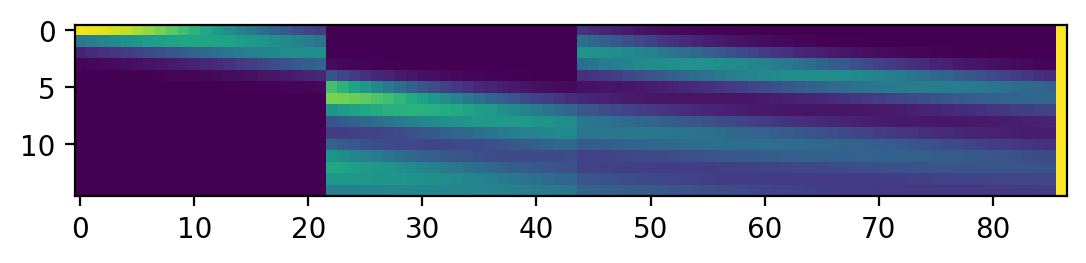

In [5]:
plt.imshow(real_deconv2.config.H, vmax=0.05)

In [6]:
from src.optimize_H import ParameterOptimizer

In [7]:
timepoints = config.timepoints
initial_values = config.params_dic

init_params_df = pd.DataFrame(initial_values, index=['value']).T
init_params_df = init_params_df.drop('alpha')
init_params_df

,value
mu0,-0.151000
delta,10.895300
sigma0,10.631000
sigmav,0.129700
lambda,60.209300
gamma1,0.333875
gamma2,0.775000
halted,0.290600


In [8]:
bounds_dic = {
    'mu0': (-30, 30),
    'lambda': (60, 80),
    'delta': (0, 14),
    'sigma0': (1, 14),
    'sigmav': (0.01, 1.),
    'gamma1': (0., 1.),
    'gamma2': (config.params_dic['gamma2'], config.params_dic['gamma2']),
    'halted': (0.0, 1.),
}

bounds_params_df = pd.DataFrame(bounds_dic, index=['min', 'max']).T
params_df = init_params_df.join(bounds_params_df)
params_df


,value,min,max
mu0,-0.151000,-30.000,30.000
delta,10.895300,0.000,14.000
sigma0,10.631000,1.000,14.000
sigmav,0.129700,0.010,1.000
lambda,60.209300,60.000,80.000
gamma1,0.333875,0.000,1.000
gamma2,0.775000,0.775,0.775
halted,0.290600,0.000,1.000


In [9]:
real_deconv2.setup_deconvolution(real_deconv2.config)

Initializing N using config H.
Initializing B using timepoint 0


In [10]:
real_deconv2.iterative_deconvolution_updates(20)

Iteration 0
0/704 - 00:00:00.059
100/704 - 00:00:00.112
200/704 - 00:00:00.166
300/704 - 00:00:00.219
400/704 - 00:00:00.271
500/704 - 00:00:00.325
600/704 - 00:00:00.379
700/704 - 00:00:00.432
Iteration completed 00:00:01.354, rn=0.004449683714007107
Iteration 1
0/704 - 00:00:01.356
100/704 - 00:00:01.409
200/704 - 00:00:01.462
300/704 - 00:00:01.516
400/704 - 00:00:01.569
500/704 - 00:00:01.623
600/704 - 00:00:01.677
700/704 - 00:00:01.730
Iteration completed 00:00:02.356, rn=0.003491725499913459
Iteration 2
0/704 - 00:00:02.357
100/704 - 00:00:02.410
200/704 - 00:00:02.464
300/704 - 00:00:02.519
400/704 - 00:00:02.574
500/704 - 00:00:02.631
600/704 - 00:00:02.684
700/704 - 00:00:02.739
Iteration completed 00:00:03.375, rn=0.003133963037417392
Iteration 3
0/704 - 00:00:03.377
100/704 - 00:00:03.430
200/704 - 00:00:03.482
300/704 - 00:00:03.535
400/704 - 00:00:03.588
500/704 - 00:00:03.643
600/704 - 00:00:03.699
700/704 - 00:00:03.754
Iteration completed 00:00:04.285, rn=0.00293125379

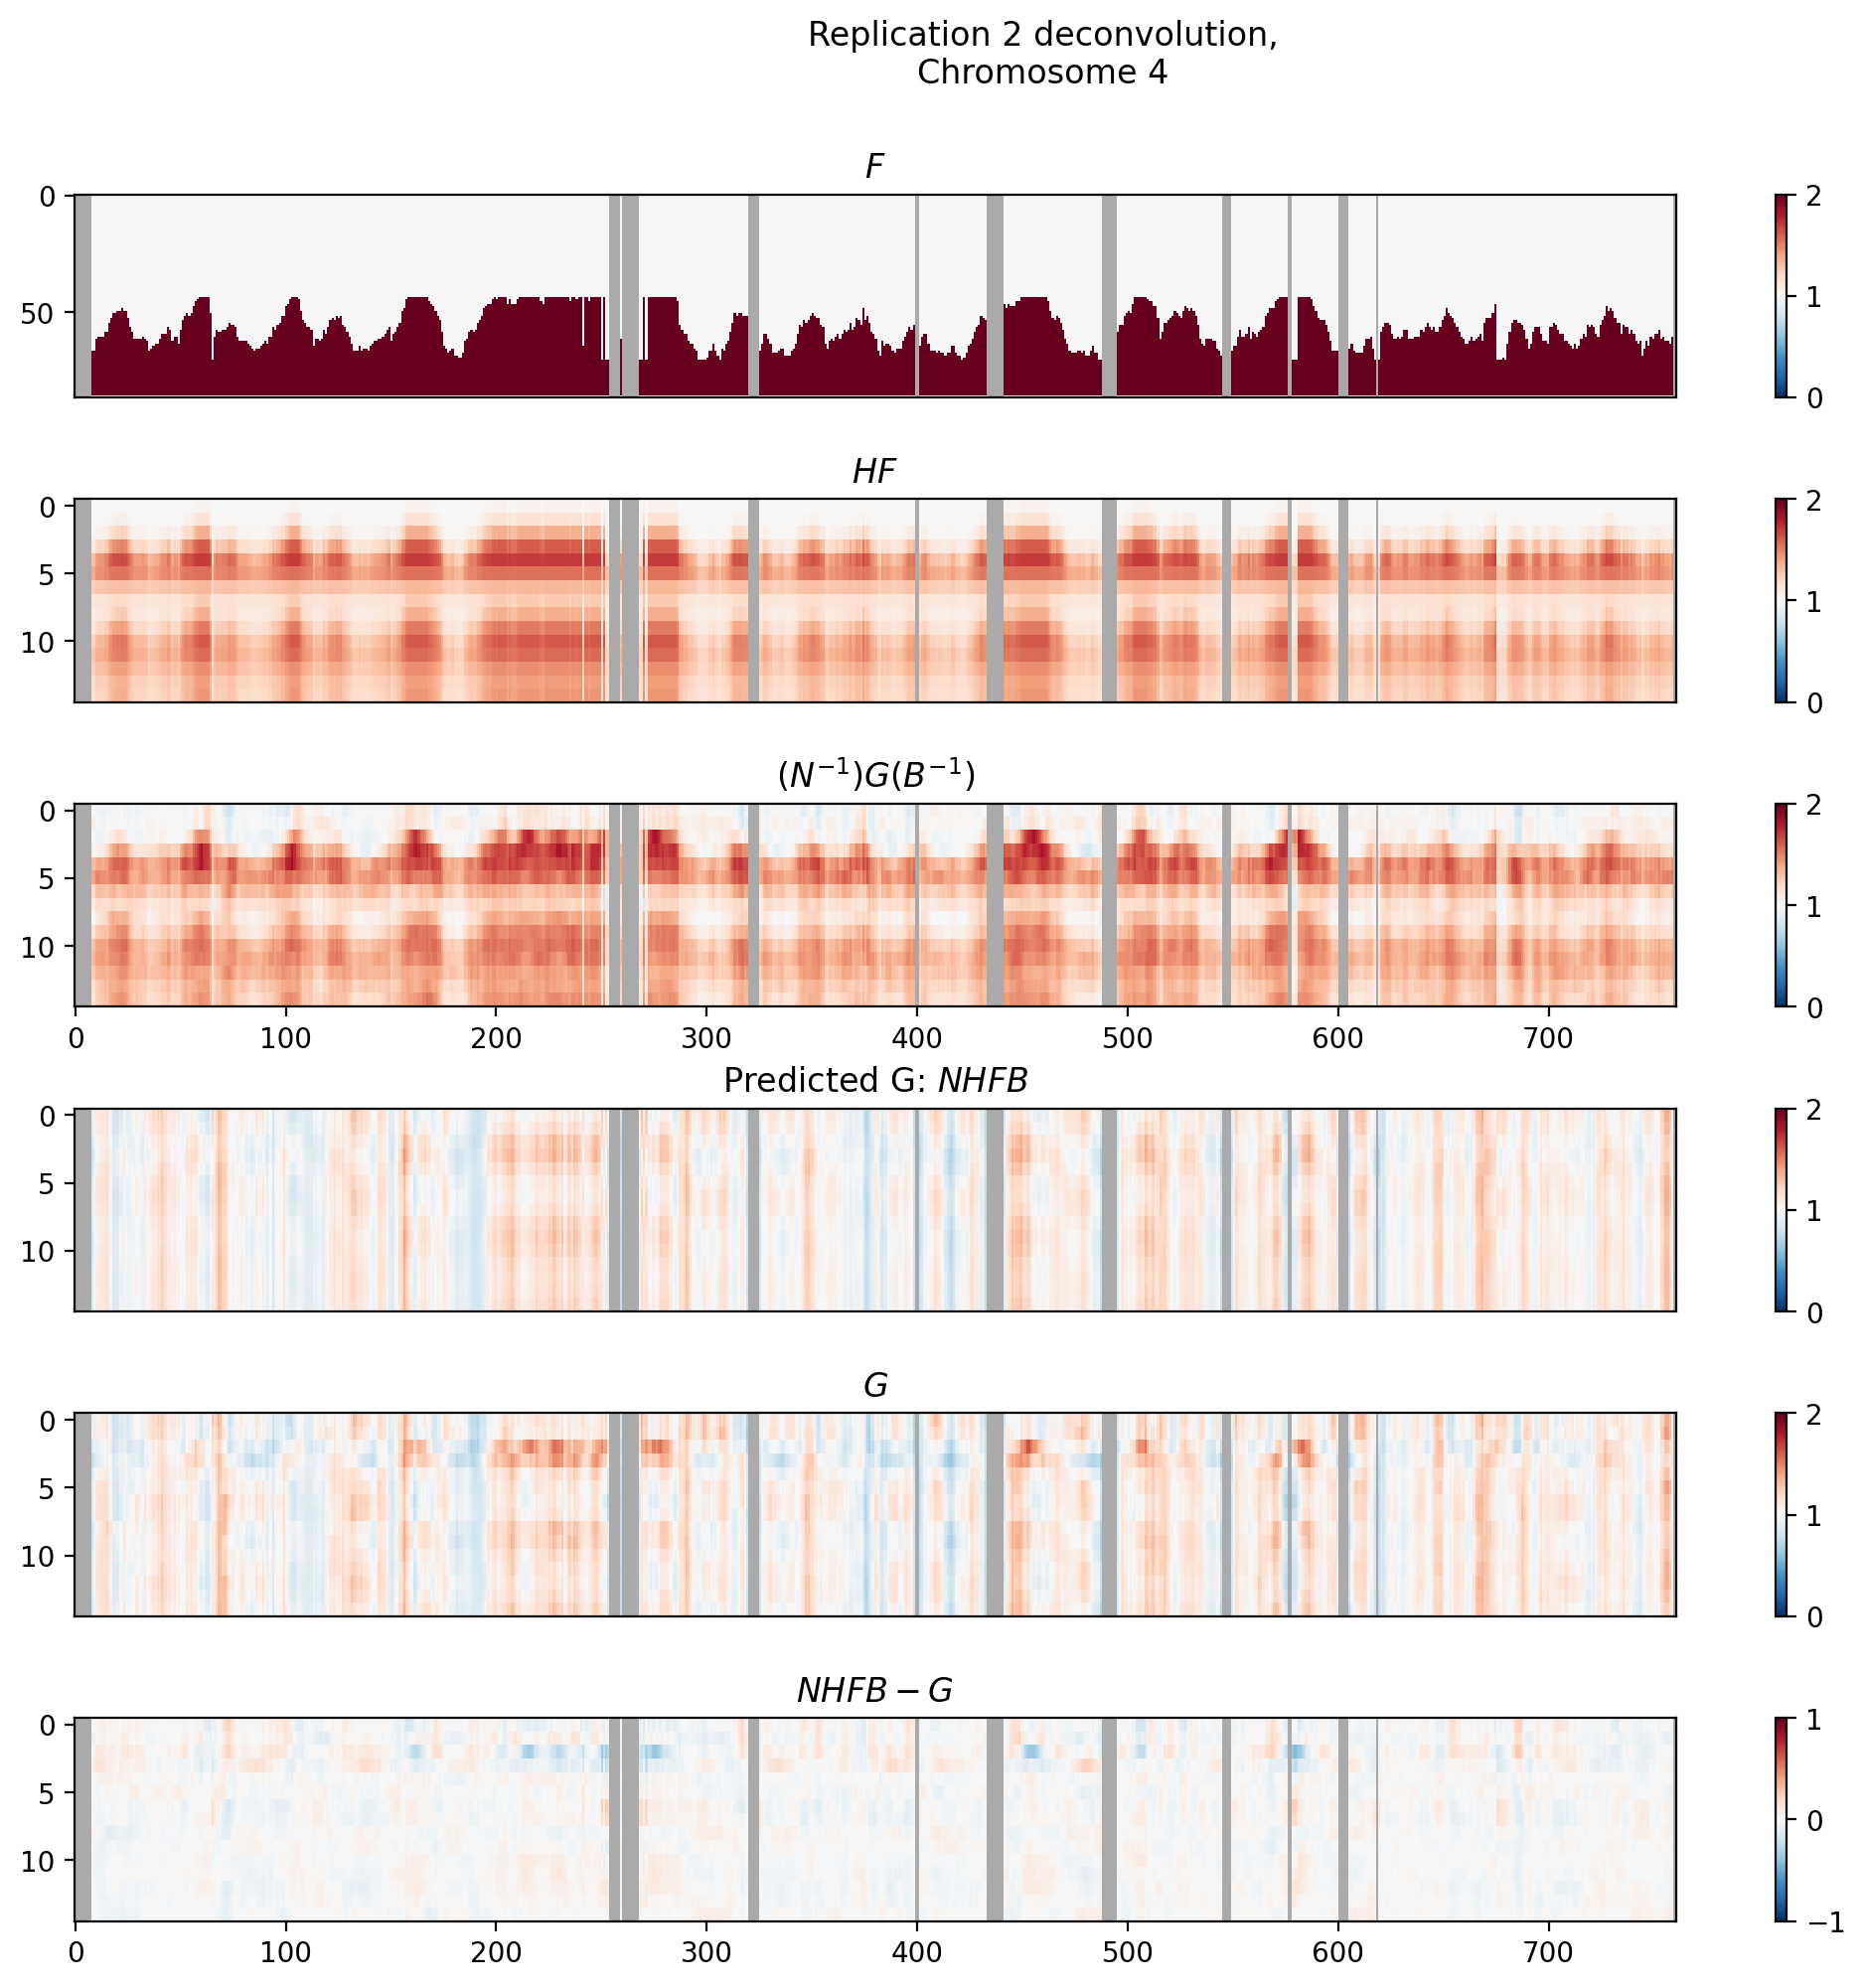

In [11]:
real_deconv2.plot_heatmaps()

In [12]:
optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv2.N,
    F=real_deconv2.F,
    B=real_deconv2.B,
    G=real_deconv2.G
)


In [13]:
from src.timer import Timer
from src.single_G1_config import calcH

timer = Timer()

num_epochs = 1000
num_iterations_N_B = 5
update_params_df = pd.DataFrame()

N = real_deconv2.N
B = real_deconv2.B

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv2.N,
    F=real_deconv2.F,
    B=real_deconv2.B,
    G=real_deconv2.G
)

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    
    optimizer.optimize(maxiter=1000, verbose=True)

    real_deconv2.H = optimizer.current_H
        
    real_deconv2.iterative_deconvolution_updates(
        total_iterations=num_iterations_N_B, timer=timer,
        initial_B=B, initial_N=N)
    timer.print_time()
    
    params_row = pd.DataFrame([optimizer.params_df['value']], index=[epoch])
    params_row['opt_H_loss'] = optimizer.rn
    params_row['F_rn'] = real_deconv2.rn

    update_params_df = pd.concat([update_params_df, params_row])
    
    optimizer.N = real_deconv2.N
    optimizer.B = real_deconv2.B
    optimizer.F = real_deconv2.F
    
    N = real_deconv2.N
    B = real_deconv2.B

    print(update_params_df.iloc[-1])


Epoch:  0
Optimization [1]: Current loss: 0.002654616583702164
Optimization [101]: Current loss: 0.002612090800163678
Optimization [201]: Current loss: 0.002611079184580677
Optimization [301]: Current loss: 0.0026070345124805357
Optimization terminated successfully.
         Current function value: 0.002607
         Iterations: 248
         Function evaluations: 376
Iteration 0
0/704 - 00:01:28.496
100/704 - 00:01:28.554
200/704 - 00:01:28.616
300/704 - 00:01:28.678
400/704 - 00:01:28.738
500/704 - 00:01:28.797
600/704 - 00:01:28.853
700/704 - 00:01:28.909
Iteration completed 00:01:29.133, rn=0.0025950387720945958
Iteration 1
0/704 - 00:01:29.134
100/704 - 00:01:29.189
200/704 - 00:01:29.244
300/704 - 00:01:29.298
400/704 - 00:01:29.351
500/704 - 00:01:29.408
600/704 - 00:01:29.463
700/704 - 00:01:29.517
Iteration completed 00:01:30.126, rn=0.0025394806439648014
Iteration 2
0/704 - 00:01:30.131
100/704 - 00:01:30.202
200/704 - 00:01:30.262
300/704 - 00:01:30.319
400/704 - 00:01:30.375


100/704 - 00:07:03.908
200/704 - 00:07:03.961
300/704 - 00:07:04.013
400/704 - 00:07:04.066
500/704 - 00:07:04.120
600/704 - 00:07:04.173
700/704 - 00:07:04.227
Iteration completed 00:07:05.069, rn=0.002292946569880078
Iteration 2
0/704 - 00:07:05.071
100/704 - 00:07:05.124
200/704 - 00:07:05.177
300/704 - 00:07:05.230
400/704 - 00:07:05.283
500/704 - 00:07:05.336
600/704 - 00:07:05.389
700/704 - 00:07:05.443
Iteration completed 00:07:06.313, rn=0.002290740368424594
Iteration 3
0/704 - 00:07:06.315
100/704 - 00:07:06.440
200/704 - 00:07:06.497
300/704 - 00:07:06.552
400/704 - 00:07:06.607
500/704 - 00:07:06.661
600/704 - 00:07:06.715
700/704 - 00:07:06.769
Iteration completed 00:07:07.196, rn=0.002290403993211752
Iteration 4
0/704 - 00:07:07.198
100/704 - 00:07:07.250
200/704 - 00:07:07.303
300/704 - 00:07:07.357
400/704 - 00:07:07.410
500/704 - 00:07:07.463
600/704 - 00:07:07.515
700/704 - 00:07:07.568
Iteration completed 00:07:08.726, rn=0.002290400042562576
00:07:08.726
mu0         

200/704 - 00:11:13.228
300/704 - 00:11:13.281
400/704 - 00:11:13.334
500/704 - 00:11:13.387
600/704 - 00:11:13.440
700/704 - 00:11:13.493
Iteration completed 00:11:14.083, rn=0.002212254570113403
00:11:14.083
mu0            2.428084
lambda        60.000289
delta         11.483873
sigma0         6.298752
sigmav         0.171805
gamma1         0.341812
gamma2         0.775000
halted         0.197304
opt_H_loss     0.002221
F_rn           0.002212
Name: 8, dtype: float64
Epoch:  9
Optimization [1]: Current loss: 0.0022122545701134025
Optimization [101]: Current loss: 0.002208210372200903
Optimization [201]: Current loss: 0.002207881524715257
Optimization terminated successfully.
         Current function value: 0.002208
         Iterations: 150
         Function evaluations: 240
Iteration 0
0/704 - 00:12:17.132
100/704 - 00:12:17.209
200/704 - 00:12:17.268
300/704 - 00:12:17.327
400/704 - 00:12:17.382
500/704 - 00:12:17.435
600/704 - 00:12:17.487
700/704 - 00:12:17.541
Iteration completed

100/704 - 00:16:53.680
200/704 - 00:16:53.733
300/704 - 00:16:53.786
400/704 - 00:16:53.839
500/704 - 00:16:53.892
600/704 - 00:16:53.945
700/704 - 00:16:53.998
Iteration completed 00:16:55.046, rn=0.0021748333568244833
Iteration 1
0/704 - 00:16:55.048
100/704 - 00:16:55.101
200/704 - 00:16:55.154
300/704 - 00:16:55.207
400/704 - 00:16:55.260
500/704 - 00:16:55.313
600/704 - 00:16:55.367
700/704 - 00:16:55.420
Iteration completed 00:16:56.086, rn=0.0021725241912984175
Iteration 2
0/704 - 00:16:56.087
100/704 - 00:16:56.141
200/704 - 00:16:56.196
300/704 - 00:16:56.249
400/704 - 00:16:56.302
500/704 - 00:16:56.354
600/704 - 00:16:56.408
700/704 - 00:16:56.461
Iteration completed 00:16:56.991, rn=0.0021722526255277506
Iteration 3
0/704 - 00:16:56.992
100/704 - 00:16:57.048
200/704 - 00:16:57.102
300/704 - 00:16:57.155
400/704 - 00:16:57.208
500/704 - 00:16:57.261
600/704 - 00:16:57.314
700/704 - 00:16:57.368
Iteration completed 00:16:58.063, rn=0.0021722519144897244
Iteration 4
0/704 - 0

200/704 - 00:21:53.821
300/704 - 00:21:53.874
400/704 - 00:21:53.929
500/704 - 00:21:53.982
600/704 - 00:21:54.035
700/704 - 00:21:54.089
Iteration completed 00:21:54.854, rn=0.002128759436122819
Iteration 4
0/704 - 00:21:54.855
100/704 - 00:21:54.908
200/704 - 00:21:54.961
300/704 - 00:21:55.015
400/704 - 00:21:55.069
500/704 - 00:21:55.122
600/704 - 00:21:55.177
700/704 - 00:21:55.231
Iteration completed 00:21:55.965, rn=0.0021282662700859035
00:21:55.965
mu0            3.609536
lambda        60.000342
delta          9.492984
sigma0         6.526443
sigmav         0.167261
gamma1         0.368558
gamma2         0.775000
halted         0.087084
opt_H_loss     0.002134
F_rn           0.002128
Name: 17, dtype: float64
Epoch:  18
Optimization [1]: Current loss: 0.0021282662700859035
Optimization [101]: Current loss: 0.002126806238709866
Optimization [201]: Current loss: 0.0021265666666246755
Optimization terminated successfully.
         Current function value: 0.002126
         Iteratio

...

Optimization [101]: Current loss: 0.0018130353690862537
Optimization terminated successfully.
         Current function value: 0.001813
         Iterations: 50
         Function evaluations: 101
Iteration 0
0/704 - 08:17:16.114
100/704 - 08:17:16.163
200/704 - 08:17:16.211
300/704 - 08:17:16.260
400/704 - 08:17:16.308
500/704 - 08:17:16.359
600/704 - 08:17:16.408
700/704 - 08:17:16.457
Iteration completed 08:17:17.658, rn=0.0018130353690862541
Iteration 1
0/704 - 08:17:17.659
100/704 - 08:17:17.706
200/704 - 08:17:17.755
300/704 - 08:17:17.805
400/704 - 08:17:17.854
500/704 - 08:17:17.905
600/704 - 08:17:17.958
700/704 - 08:17:18.004
Iteration completed 08:17:18.521, rn=0.0018130343769071086
Iteration 2
0/704 - 08:17:18.523
100/704 - 08:17:18.569
200/704 - 08:17:18.615
300/704 - 08:17:18.663
400/704 - 08:17:18.708
500/704 - 08:17:18.754
600/704 - 08:17:18.801
700/704 - 08:17:18.849
Iteration completed 08:17:19.518, rn=0.0018130343914550923
Iteration 3
0/704 - 08:17:19.520
100/704 - 08:

100/704 - 08:19:14.749
200/704 - 08:19:14.837
300/704 - 08:19:14.914
400/704 - 08:19:15.005
500/704 - 08:19:15.078
600/704 - 08:19:15.128
700/704 - 08:19:15.173
Iteration completed 08:19:15.400, rn=0.0018130754012484478
08:19:15.400
mu0           13.384629
lambda        64.934016
delta          0.354804
sigma0         5.149303
sigmav         0.147374
gamma1         0.487992
gamma2         0.775000
halted         0.000114
opt_H_loss     0.001813
F_rn           0.001813
Name: 984, dtype: float64
Epoch:  985
Optimization [1]: Current loss: 0.0018130754012484493
Optimization terminated successfully.
         Current function value: 0.001813
         Iterations: 44
         Function evaluations: 92
Iteration 0
0/704 - 08:19:36.875
100/704 - 08:19:36.930
200/704 - 08:19:36.976
300/704 - 08:19:37.021
400/704 - 08:19:37.067
500/704 - 08:19:37.112
600/704 - 08:19:37.158
700/704 - 08:19:37.203
Iteration completed 08:19:37.688, rn=0.0018130769241189485
Iteration 1
0/704 - 08:19:37.689
100/704 - 0

100/704 - 08:21:39.281
200/704 - 08:21:39.353
300/704 - 08:21:39.443
400/704 - 08:21:39.515
500/704 - 08:21:39.620
600/704 - 08:21:39.703
700/704 - 08:21:39.758
Iteration completed 08:21:40.798, rn=0.0018130957479723893
Iteration 3
0/704 - 08:21:40.800
100/704 - 08:21:40.847
200/704 - 08:21:40.898
300/704 - 08:21:40.947
400/704 - 08:21:40.993
500/704 - 08:21:41.042
600/704 - 08:21:41.090
700/704 - 08:21:41.141
Iteration completed 08:21:41.627, rn=0.001813095747971425
Iteration 4
0/704 - 08:21:41.628
100/704 - 08:21:41.682
200/704 - 08:21:41.733
300/704 - 08:21:41.786
400/704 - 08:21:41.842
500/704 - 08:21:41.898
600/704 - 08:21:41.952
700/704 - 08:21:42.010
Iteration completed 08:21:42.373, rn=0.0018130957479714253
08:21:42.373
mu0           13.390753
lambda        64.939214
delta          0.330522
sigma0         5.146762
sigmav         0.147409
gamma1         0.488030
gamma2         0.775000
halted         0.000127
opt_H_loss     0.001813
F_rn           0.001813
Name: 989, dtype: floa

100/704 - 08:24:10.826
200/704 - 08:24:10.887
300/704 - 08:24:10.937
400/704 - 08:24:10.987
500/704 - 08:24:11.033
600/704 - 08:24:11.079
700/704 - 08:24:11.127
Iteration completed 08:24:11.846, rn=0.0018130925113467187
Iteration 1
0/704 - 08:24:11.848
100/704 - 08:24:11.893
200/704 - 08:24:11.939
300/704 - 08:24:11.988
400/704 - 08:24:12.034
500/704 - 08:24:12.080
600/704 - 08:24:12.126
700/704 - 08:24:12.176
Iteration completed 08:24:13.155, rn=0.0018130966813068785
Iteration 2
0/704 - 08:24:13.157
100/704 - 08:24:13.203
200/704 - 08:24:13.249
300/704 - 08:24:13.296
400/704 - 08:24:13.343
500/704 - 08:24:13.389
600/704 - 08:24:13.435
700/704 - 08:24:13.482
Iteration completed 08:24:14.306, rn=0.0018130966923001598
Iteration 3
0/704 - 08:24:14.309
100/704 - 08:24:14.363
200/704 - 08:24:14.411
300/704 - 08:24:14.463
400/704 - 08:24:14.519
500/704 - 08:24:14.571
600/704 - 08:24:14.619
700/704 - 08:24:14.666
Iteration completed 08:24:15.778, rn=0.0018130966922997975
Iteration 4
0/704 - 0

Iteration completed 08:26:21.442, rn=0.001813083281732355
08:26:21.442
mu0           13.392503
lambda        64.940950
delta          0.356923
sigma0         5.146571
sigmav         0.147407
gamma1         0.488054
gamma2         0.775000
halted         0.000143
opt_H_loss     0.001813
F_rn           0.001813
Name: 998, dtype: float64
Epoch:  999
Optimization [1]: Current loss: 0.0018130832817323552
Optimization [101]: Current loss: 0.001813084816655185
Optimization terminated successfully.
         Current function value: 0.001813
         Iterations: 57
         Function evaluations: 109
Iteration 0
0/704 - 08:26:50.189
100/704 - 08:26:50.243
200/704 - 08:26:50.296
300/704 - 08:26:50.346
400/704 - 08:26:50.403
500/704 - 08:26:50.455
600/704 - 08:26:50.510
700/704 - 08:26:50.567
Iteration completed 08:26:50.905, rn=0.0018130819996465479
Iteration 1
0/704 - 08:26:50.906
100/704 - 08:26:50.958
200/704 - 08:26:51.016
300/704 - 08:26:51.068
400/704 - 08:26:51.119
500/704 - 08:26:51.180
60

In [14]:
config.params_dic#get_Hpositions_for_phase('S')

{'mu0': 13.389312006913713,
 'delta': 0.36650200817952927,
 'sigma0': 5.144680971823291,
 'sigmav': 0.14743316599128364,
 'lambda': 64.93803020964495,
 'gamma1': 0.4880379246794865,
 'gamma2': 0.775,
 'halted': 0.00013312181494751929,
 'alpha': 20}

Text(0.5, 0.98, 'Cell cycle parameter updates, 1000 epochs')

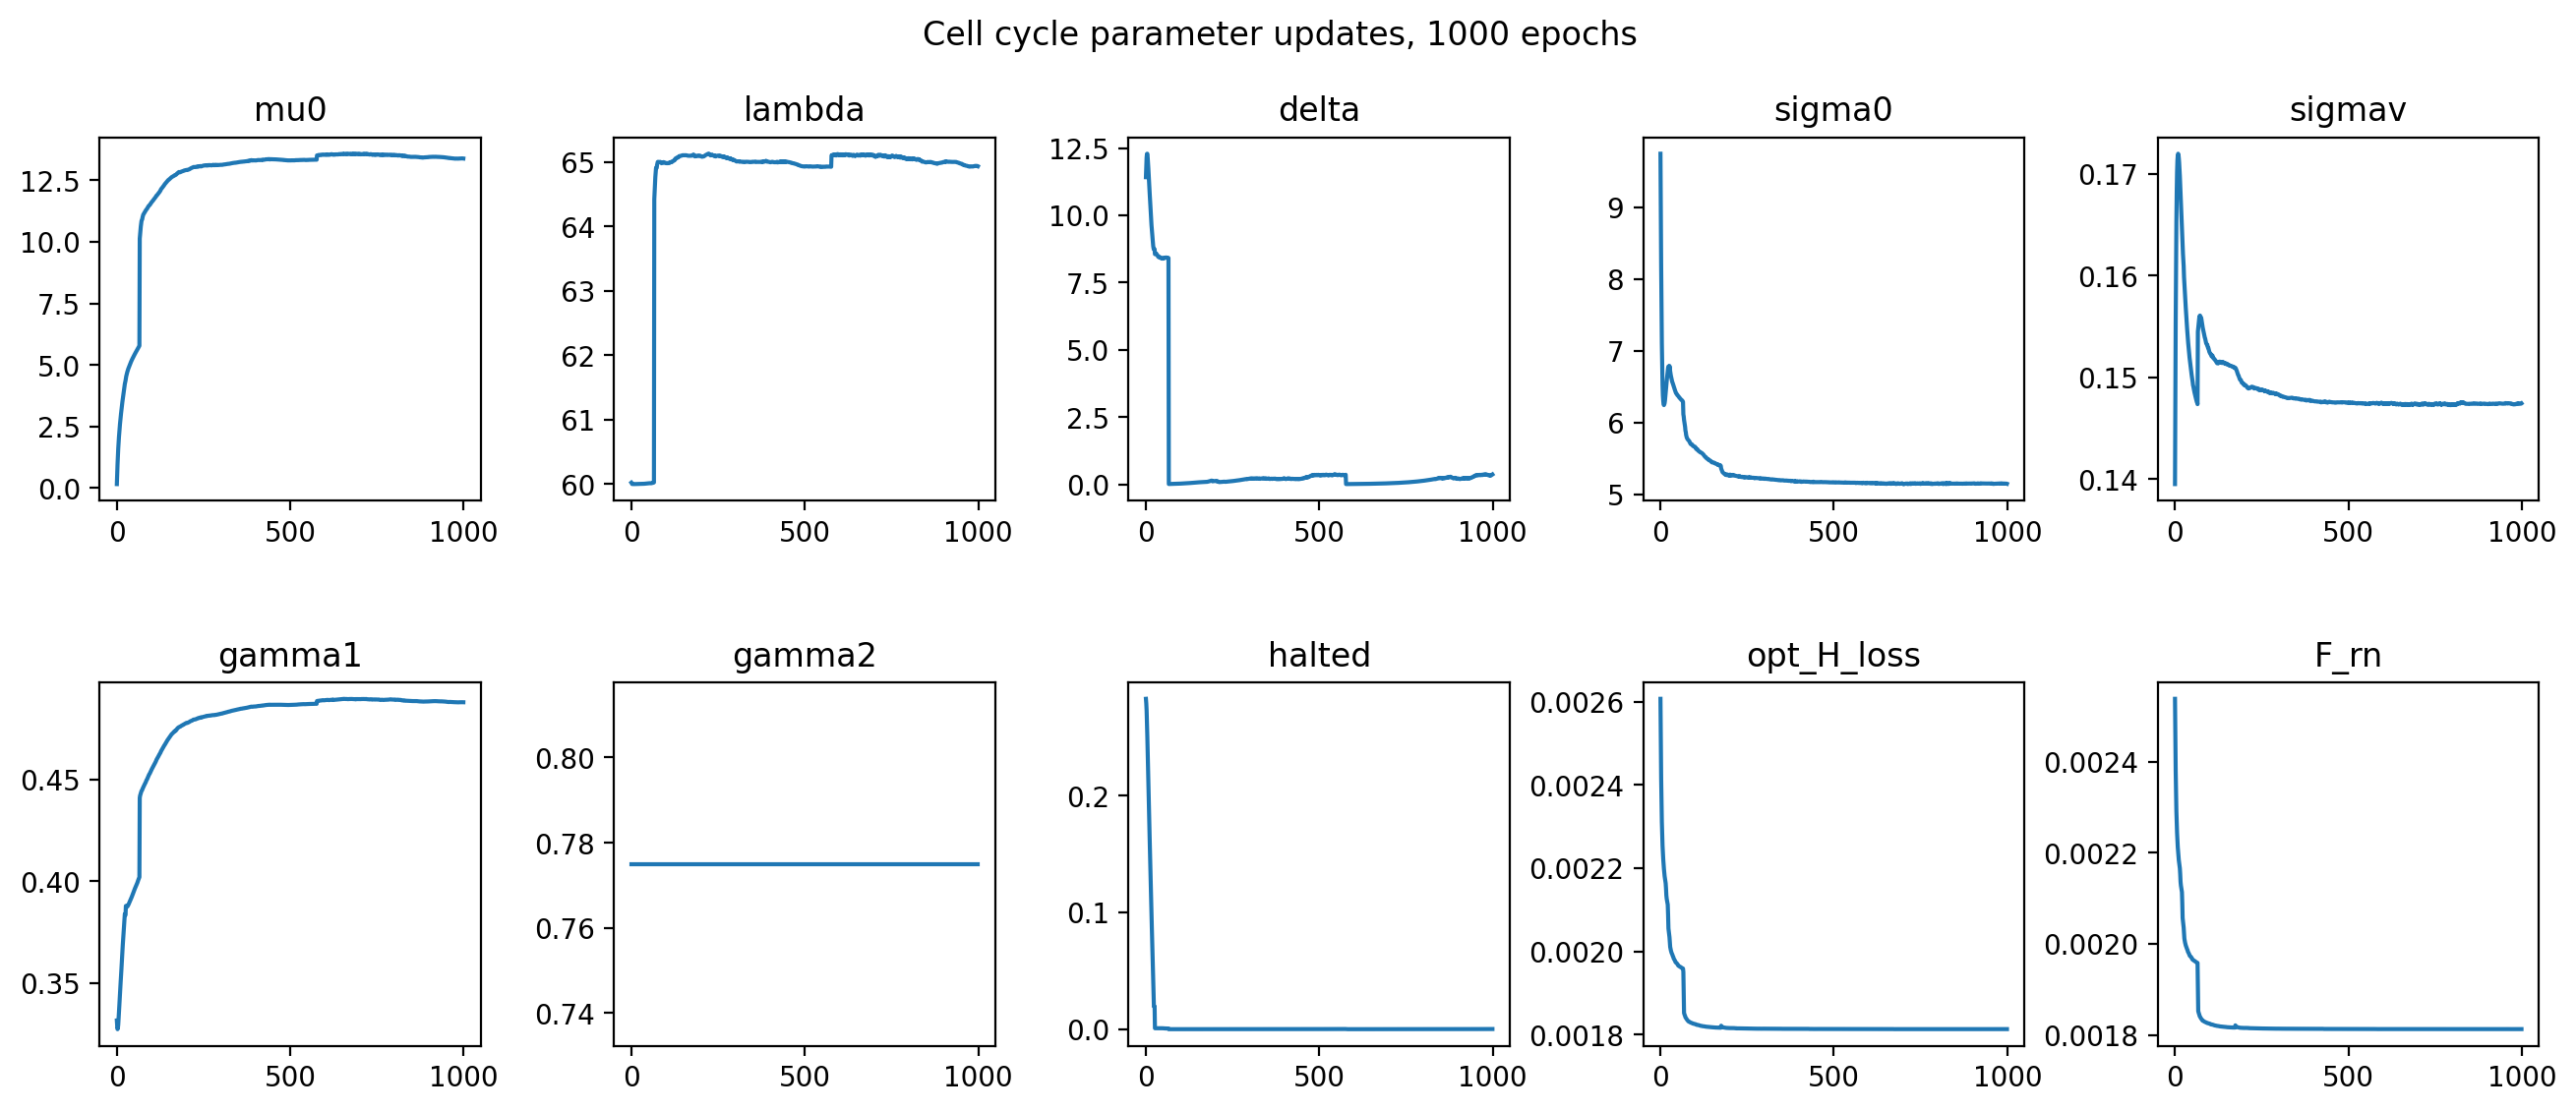

In [15]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

In [16]:
real_deconv2.config.get_s_g2m_indices()

(array([44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
        61, 62, 63, 64, 65, 66, 67]),
 array([68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
        85]))

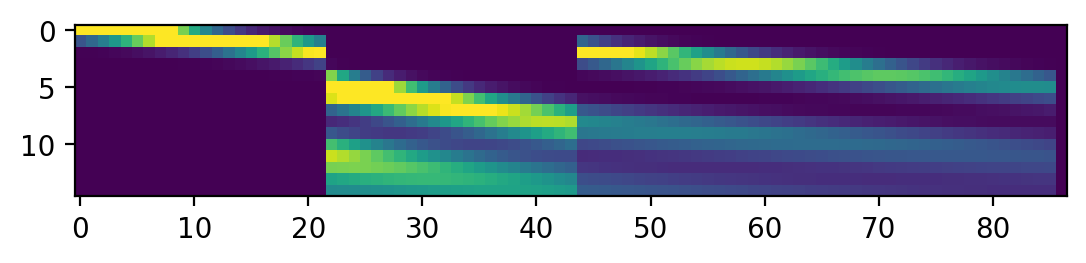

In [17]:
plt.imshow(real_deconv2.H, vmax=0.05)

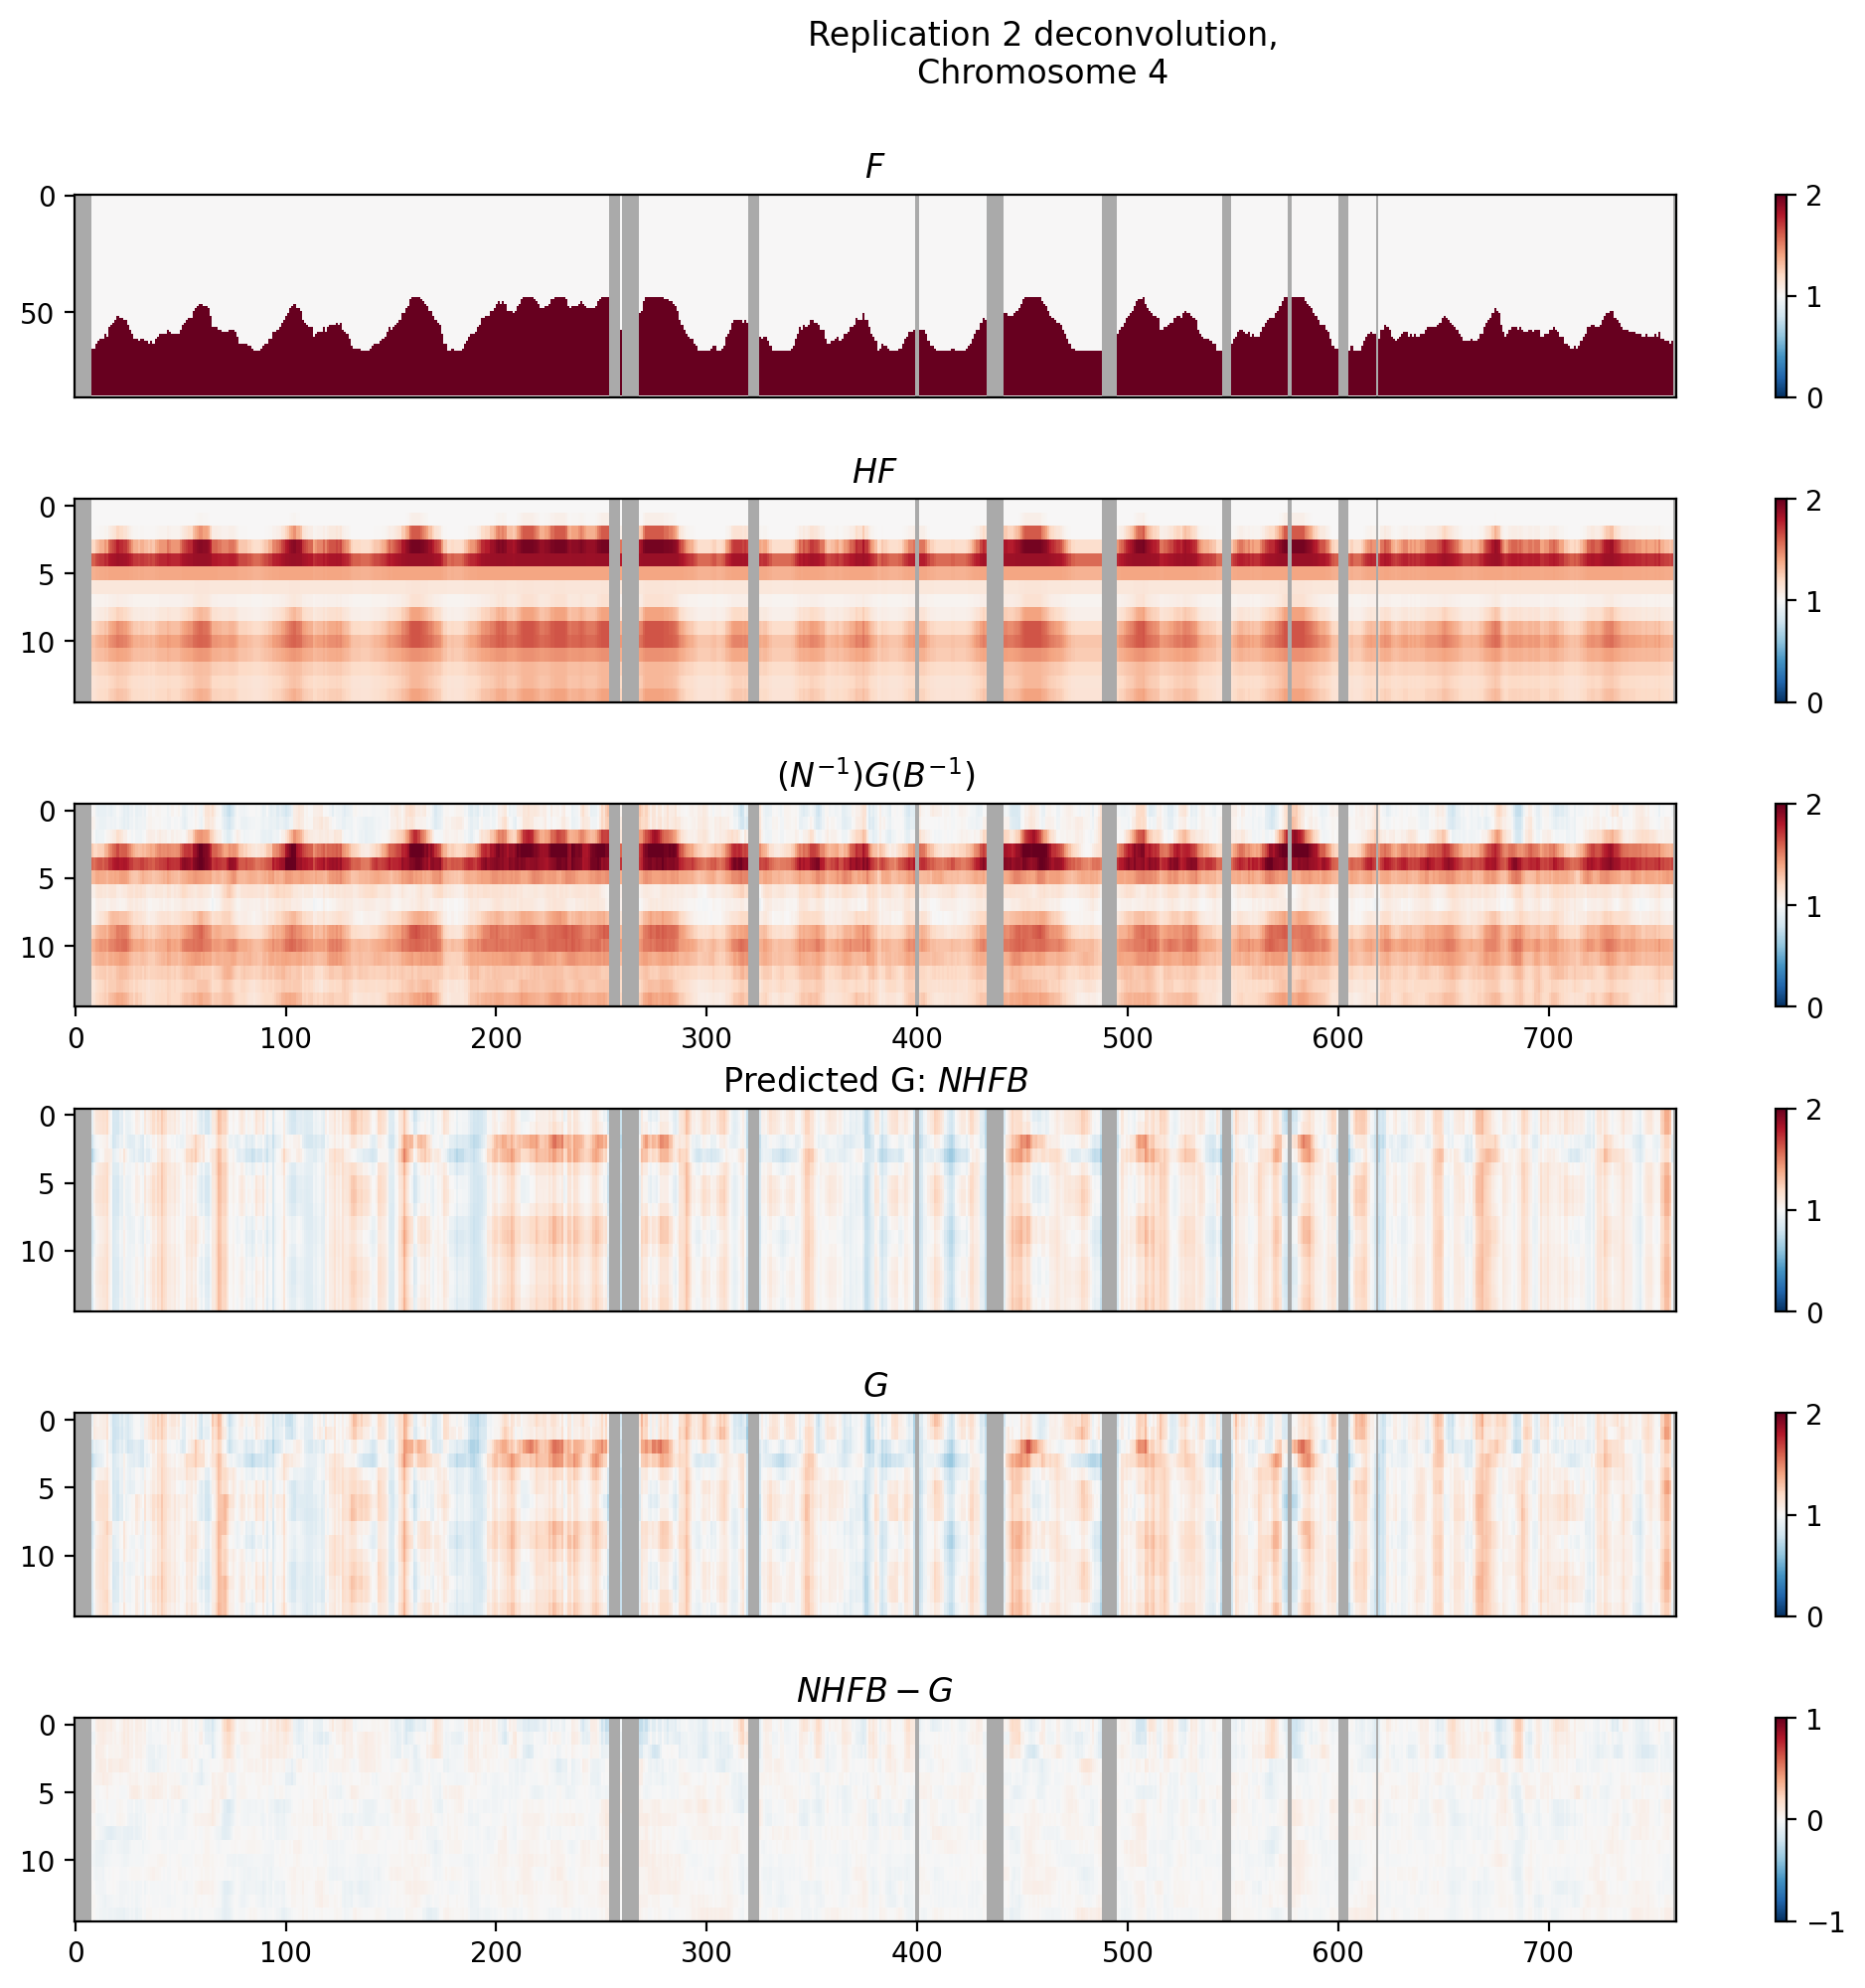

In [18]:
real_deconv2.plot_heatmaps()

Text(0.5, 0.98, 'Average single cell copy number, replicate 2, chrIV')

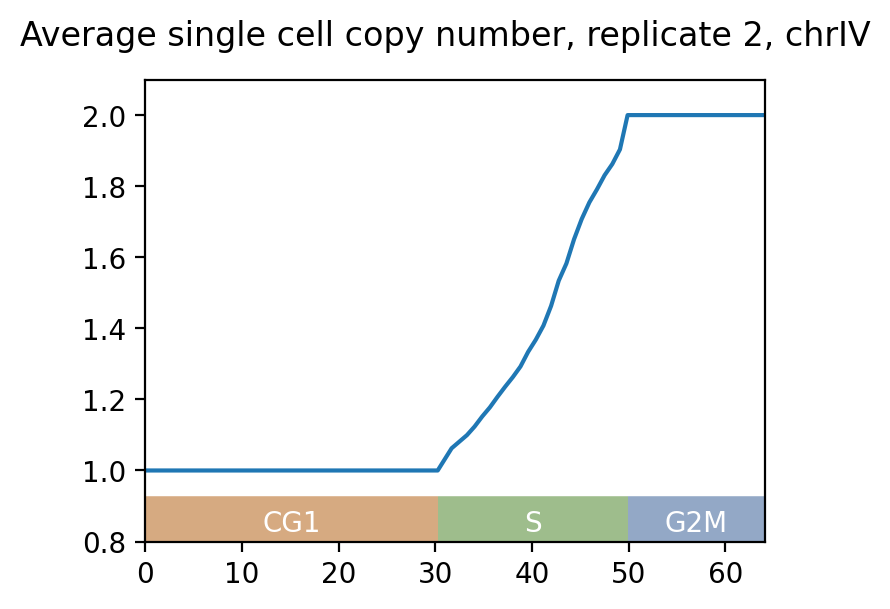

In [22]:
from src.chromatin_model import draw_phase_label_annotations

fig = plt.figure(figsize=(4, 3))
t_indices = config.get_Hpositions_for_branch('t')
t_tps = config.get_timepoints_for_branch('t')
plt.plot(t_tps, real_deconv2.F.mean(axis=1)[t_indices])
draw_phase_label_annotations(plt.gca(), config, flip=True, annotations_x=0.85)
plt.xlim(t_tps[0], t_tps[-1])
plt.ylim(0.8, 2.1)
plt.suptitle("Average single cell copy number, replicate 2, chrIV")


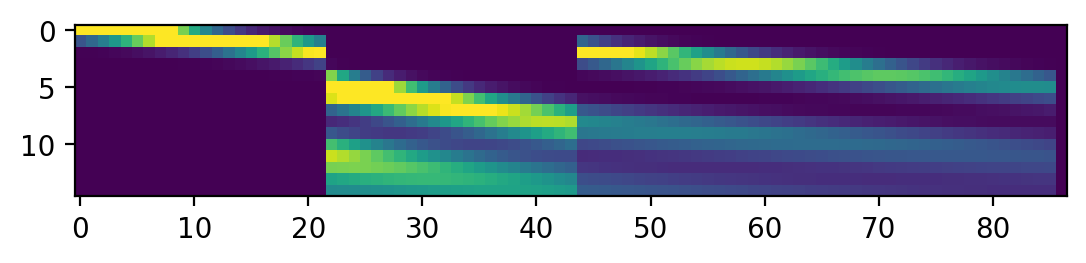

In [20]:
plt.imshow(config.H, vmax=0.05)

In [21]:
config.params_dic

{'mu0': 13.389312006913713,
 'delta': 0.36650200817952927,
 'sigma0': 5.144680971823291,
 'sigmav': 0.14743316599128364,
 'lambda': 64.93803020964495,
 'gamma1': 0.4880379246794865,
 'gamma2': 0.775,
 'halted': 0.00013312181494751929,
 'alpha': 20}